In [2]:
import pandas as pd
from datetime import datetime, timedelta, UTC
import matplotlib.pyplot as plt
import numpy as np

df= pd.read_csv('/app_user_behavior_dataset.csv')
df


,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149995,23,Male,Germany,Android,1.1,10,8.68,70.21,15,...,9,Free,4,0,1,4.0,0.39,68.97,121,Google Ads
49996,149996,34,Female,India,iOS,1.1,6,3.30,41.51,9,...,10,Basic,5,5,1,5.0,0.12,64.84,133,Google Ads
49997,149997,43,Male,India,iOS,1.2,6,21.67,58.00,9,...,27,Free,9,1,2,1.0,0.60,69.70,1120,Google Ads
49998,149998,41,Male,India,iOS,1.2,13,14.29,37.93,10,...,11,Free,6,2,2,4.0,0.22,71.00,1175,Google Ads


Understanding the Dataset:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        50000 non-null  int64  
 1   age                            50000 non-null  int64  
 2   gender                         50000 non-null  object 
 3   country                        50000 non-null  object 
 4   device_type                    50000 non-null  object 
 5   app_version                    50000 non-null  float64
 6   sessions_per_week              50000 non-null  int64  
 7   avg_session_duration_min       50000 non-null  float64
 8   daily_active_minutes           50000 non-null  float64
 9   feature_clicks_per_session     50000 non-null  int64  
 10  notifications_opened_per_week  50000 non-null  int64  
 11  in_app_search_count            50000 non-null  int64  
 12  pages_viewed_per_session       50000 non-null 

In [4]:
df.describe()

,user_id,age,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,notifications_opened_per_week,in_app_search_count,pages_viewed_per_session,crash_events_last_30_days,support_tickets_raised,days_since_last_login,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,44978.000000,50000.000000,50000.000000,50000.000000
mean,124999.500000,38.513040,1.476126,7.999680,13.149842,45.164537,12.013920,4.99662,3.999060,13.470760,0.397520,0.19666,22.038240,5.995800,3.002260,2.001440,3.630664,0.500834,64.940409,603.785100
std,14433.901067,12.094948,0.470158,2.829438,8.946944,19.505118,3.480289,2.23518,1.997763,6.343635,0.633992,0.44442,12.985237,2.453313,1.731818,1.413435,1.087339,0.288578,14.838827,345.567524
min,100000.000000,18.000000,1.000000,0.000000,0.060000,5.000000,1.000000,0.00000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,10.000000,7.000000
25%,112499.750000,28.000000,1.100000,6.000000,6.570000,31.650000,10.000000,3.00000,3.000000,8.000000,0.000000,0.00000,11.000000,4.000000,2.000000,1.000000,3.000000,0.250000,54.900000,302.000000
50%,124999.500000,39.000000,1.200000,8.000000,11.240000,45.210000,12.000000,5.00000,4.000000,13.000000,0.000000,0.00000,22.000000,6.000000,3.000000,2.000000,4.000000,0.500000,65.025000,604.000000
75%,137499.250000,49.000000,2.000000,10.000000,17.570000,58.440000,14.000000,6.00000,5.000000,19.000000,1.000000,0.00000,33.000000,8.000000,4.000000,3.000000,4.000000,0.750000,75.090000,906.000000
max,149999.000000,59.000000,2.100000,26.000000,91.400000,129.130000,28.000000,16.00000,19.000000,24.000000,5.000000,4.00000,44.000000,19.000000,13.000000,11.000000,5.000000,1.000000,100.000000,1199.000000


Plotting Engagement score:

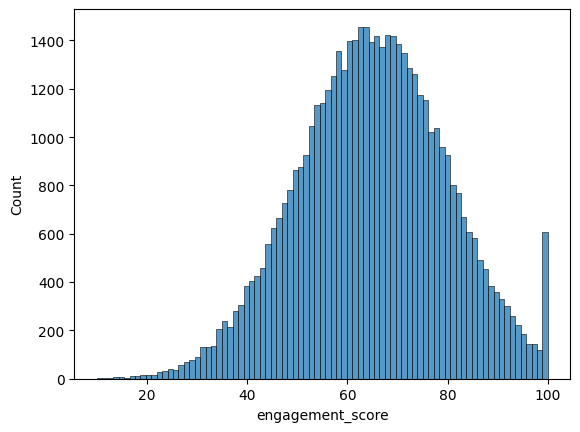

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['engagement_score'])
plt.show()


Finding Missing values of the dataset

In [6]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)
df

Missing Values:
user_id                             0
age                                 0
gender                              0
country                             0
device_type                         0
app_version                         0
sessions_per_week                   0
avg_session_duration_min            0
daily_active_minutes                0
feature_clicks_per_session          0
notifications_opened_per_week       0
in_app_search_count                 0
pages_viewed_per_session            0
crash_events_last_30_days           0
support_tickets_raised              0
days_since_last_login               0
subscription_type                   0
ads_clicked_last_30_days            0
content_downloads                   0
social_shares                       0
rating_given                     5022
churn_risk_score                    0
engagement_score                    0
account_age_days                    0
marketing_source                    0
dtype: int64


,user_id,age,gender,country,device_type,app_version,sessions_per_week,avg_session_duration_min,daily_active_minutes,feature_clicks_per_session,...,days_since_last_login,subscription_type,ads_clicked_last_30_days,content_downloads,social_shares,rating_given,churn_risk_score,engagement_score,account_age_days,marketing_source
0,100000,56,Female,India,iOS,2.1,5,3.41,52.71,13,...,20,Basic,9,5,2,NaN,0.31,55.79,1152,Referral
1,100001,46,Male,UK,iOS,1.0,8,24.44,42.03,7,...,7,Free,8,3,3,3.0,0.87,82.39,1059,Email Campaign
2,100002,32,Female,UK,iOS,1.2,12,5.34,76.69,7,...,33,Free,11,6,1,2.0,0.63,42.49,678,Google Ads
3,100003,25,Male,India,Android,2.0,5,3.98,65.38,16,...,17,Basic,6,3,1,3.0,0.43,62.81,92,Organic
4,100004,38,Male,Australia,Android,1.0,10,12.85,57.06,13,...,21,Basic,4,4,2,5.0,0.43,38.21,772,Email Campaign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149995,23,Male,Germany,Android,1.1,10,8.68,70.21,15,...,9,Free,4,0,1,4.0,0.39,68.97,121,Google Ads
49996,149996,34,Female,India,iOS,1.1,6,3.30,41.51,9,...,10,Basic,5,5,1,5.0,0.12,64.84,133,Google Ads
49997,149997,43,Male,India,iOS,1.2,6,21.67,58.00,9,...,27,Free,9,1,2,1.0,0.60,69.70,1120,Google Ads
49998,149998,41,Male,India,iOS,1.2,13,14.29,37.93,10,...,11,Free,6,2,2,4.0,0.22,71.00,1175,Google Ads


Step 1: Filling the Missing values

In [7]:

# 1. Fill missing values and SAVE the result back to the dataframe
df['rating_given'] = df['rating_given'].fillna(df['rating_given'].median())

# Verification: This should now print 0 for rating_given
print(df.isnull().sum())



user_id                          0
age                              0
gender                           0
country                          0
device_type                      0
app_version                      0
sessions_per_week                0
avg_session_duration_min         0
daily_active_minutes             0
feature_clicks_per_session       0
notifications_opened_per_week    0
in_app_search_count              0
pages_viewed_per_session         0
crash_events_last_30_days        0
support_tickets_raised           0
days_since_last_login            0
subscription_type                0
ads_clicked_last_30_days         0
content_downloads                0
social_shares                    0
rating_given                     0
churn_risk_score                 0
engagement_score                 0
account_age_days                 0
marketing_source                 0
dtype: int64


In [14]:
original_shape = df.shape
print("Before cleaning:", original_shape)
print("After cleaning:", df.shape)


Before cleaning: (46051, 25)
After cleaning: (46051, 25)


Step 2: Handling Dulpicates, Outlier handling and Feature selection, correlation analysis and Scalling


Shape after removing duplicates: (46048, 26)
Shape after outlier removal: (46048, 26)
Selected features:
   age  sessions_per_week  avg_session_duration_min  daily_active_minutes  \
0   56                  5                      3.41                 52.71   
1   46                  8                     24.44                 42.03   
2   32                 12                      5.34                 76.69   
3   25                  5                      3.98                 65.38   
4   38                 10                     12.85                 57.06   

   feature_clicks_per_session  notifications_opened_per_week  \
0                          13                              5   
1                           7                              7   
2                           7                              5   
3                          16                              8   
4                          13                              7   

   pages_viewed_per_session  engagement_score  

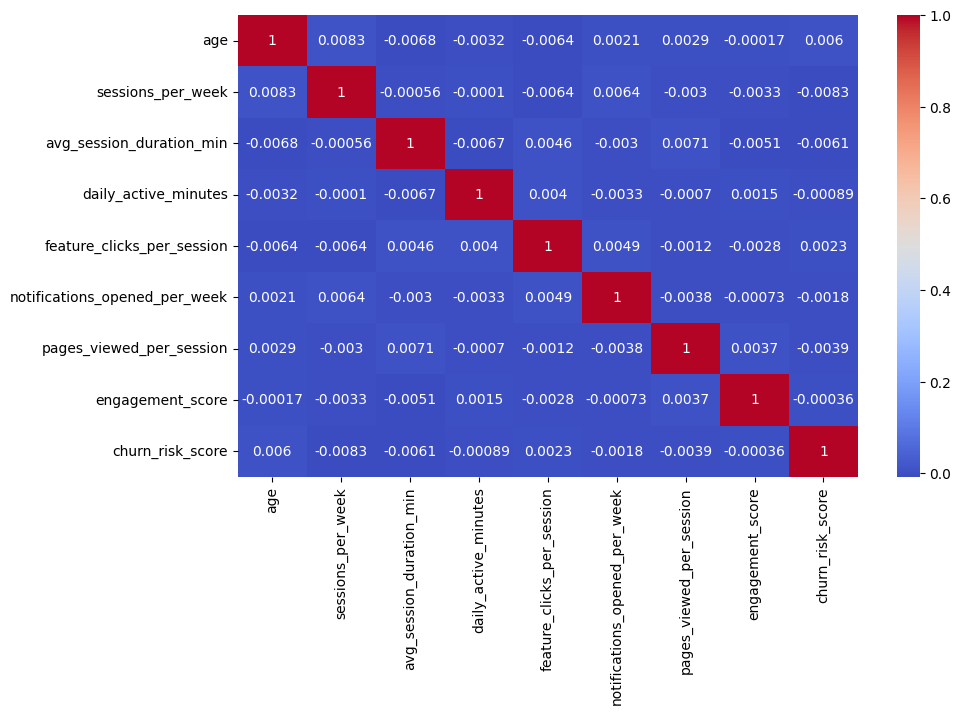

Scaled data sample:
[[ 1.44663242 -1.07067469 -1.21277219  0.40450779  0.33290069  0.04474702
  -0.85938004 -0.63599227 -0.66107845]
 [ 0.61951318  0.01322072  1.75536153 -0.15094478 -1.49391398  0.99363524
  -1.01686715  1.1813252   1.28030041]
 [-0.53845377  1.45841461 -0.9403757   1.65167562 -1.49391398  0.04474702
   1.18795244 -1.54465101  0.4482809 ]
 [-1.11743724 -1.07067469 -1.13232349  1.0634576   1.24630802  1.46807935
  -0.07194447 -0.15638443 -0.2450687 ]
 [-0.04218222  0.73581767  0.11957124  0.63074549  0.33290069  0.99363524
   0.24302976 -1.83706149 -0.2450687 ]]
Mean after scaling: 1.6713781415424814e-16
Std after scaling: 1.0


In [20]:
from sklearn.preprocessing import StandardScaler

# Step 1: Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


# Step 2: Outlier handling
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[features] < (Q1 - 1.5 * IQR)) |
          (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Shape after outlier removal:", df.shape)

# Step 3: Feature selection
features = [
   'age', 'sessions_per_week', 'avg_session_duration_min',
   'daily_active_minutes', 'feature_clicks_per_session',
  'notifications_opened_per_week', 'pages_viewed_per_session',
 'engagement_score', 'churn_risk_score'
]
X = df[features]
print("Selected features:")
print(X.head())

# Step 4. correlation analysis
plt.figure(figsize=(10,6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm')
plt.show()


# Step 5: Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data sample:")
print(X_scaled[:5])

print("Mean after scaling:", X_scaled.mean())
print("Std after scaling:", X_scaled.std())


Step 3: Finding the Optimal Clusters (Elbow Method)

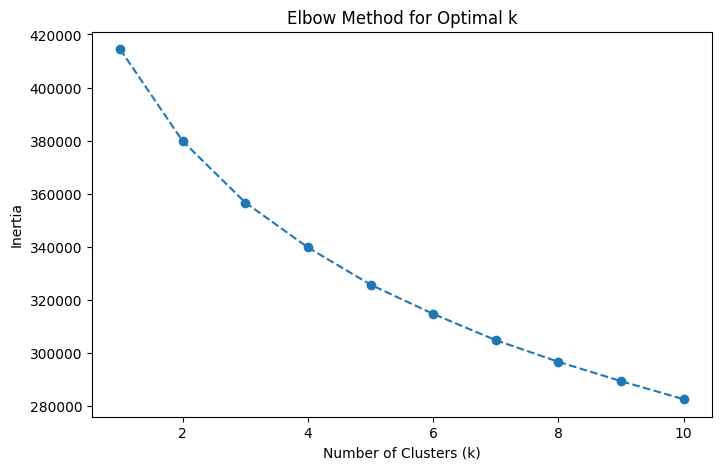

Observation: “The elbow point occurs at k=4 where inertia reduction slows significantly.”


In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

print ("Observation: “The elbow point occurs at k=4 where inertia reduction slows significantly.”")

Step 4: Training the K-Means Model

In [24]:
# Assuming optimal k=4 based on the project requirements
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("User counts per cluster:")
print(df['Cluster'].value_counts())

#Evaluate model quality by,
#1. Silhouette Score
#2. Cluster quality validation

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)


User counts per cluster:
Cluster
2    13566
0    11669
1    11475
3     9338
Name: count, dtype: int64
Silhouette Score: 0.07391973143766295


Step 5: Dimensionality Reduction for Visualization (PCA)

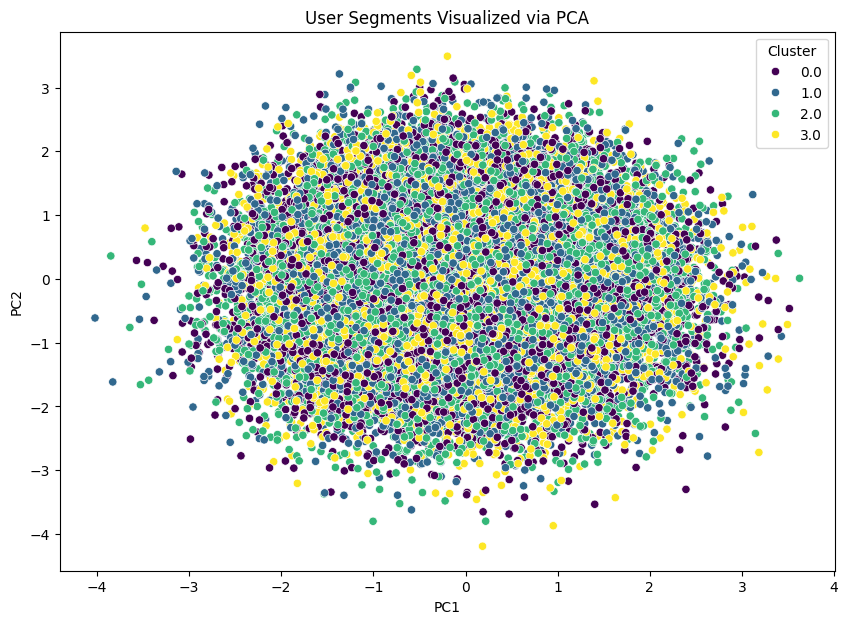

Explained Variance Ratio: [0.11315118 0.11267694]


In [26]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('User Segments Visualized via PCA')
plt.show()

# Explained variance %
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Step 6: Cluster Profiling (Business Insights)

In [27]:
#7. Cluster Naming:
#High / Moderate / Low / Occasional users
#Clusters are just numbers (0,1,2,3)
cluster_map = {
    0: 'High Engagement',
    1: 'Moderate Engagement',
    2: 'Low Engagement',
    3: 'Occasional Users'
}

df['Cluster_Label'] = df['Cluster'].map(cluster_map)


# Group by cluster and calculate the mean of each behavior
cluster_profiles = df.groupby('Cluster')[features].mean()
print("Cluster Behavioral Profiles:")
print(cluster_profiles)

Cluster Behavioral Profiles:
               age  sessions_per_week  avg_session_duration_min  \
Cluster                                                           
0        39.116805           7.756192                  9.422737   
1        38.722004           7.875294                  9.490420   
2        38.251659           8.222689                  8.908240   
3        37.866460           7.953952                 22.809978   

         daily_active_minutes  feature_clicks_per_session  \
Cluster                                                     
0                   44.677188                   11.953295   
1                   44.835006                   11.956601   
2                   45.993751                   11.800531   
3                   43.828608                   11.940994   

         notifications_opened_per_week  pages_viewed_per_session  \
Cluster                                                            
0                             4.842917                 19.617876 

In [28]:
#8.Customer-Level Identification (Weak)
# Requirement:
#Extract user lists per cluster
# User IDs per cluster
#	Counts clearly structured
for cluster in df['Cluster'].unique():
    users = df[df['Cluster'] == cluster]['user_id']
    print(f"\nCluster {cluster} Users:")
    print(users.head())

#9. Business Action Mapping
# Map clusters → actions
# Only profiling, no action mapping
def assign_action(cluster):
    if cluster == 0:
        return "Loyalty Rewards"
    elif cluster == 1:
        return "Engagement Campaigns"
    elif cluster == 2:
        return "Retention Offers"
    else:
        return "Re-engagement Notifications"

df['Business_Action'] = df['Cluster'].apply(assign_action)
print("\nBusiness Actions per Cluster:")
print(df[['Cluster', 'Business_Action']])

#10. Model Reusability / Deployment Missing
#“Real-world ready”
#	Model saving
#	Prediction for new users
import pickle

# Save model
pickle.dump(kmeans, open('kmeans_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))




Cluster 2 Users:
0     100000
3     100003
4     100004
11    100011
16    100016
Name: user_id, dtype: int64

Cluster 3 Users:
1     100001
8     100008
9     100009
12    100012
36    100036
Name: user_id, dtype: int64

Cluster 0 Users:
2     100002
5     100005
10    100010
13    100013
14    100014
Name: user_id, dtype: int64

Cluster 1 Users:
6     100006
7     100007
22    100022
23    100023
30    100030
Name: user_id, dtype: int64

Business Actions per Cluster:
       Cluster              Business_Action
0            2             Retention Offers
1            3  Re-engagement Notifications
2            0              Loyalty Rewards
3            2             Retention Offers
4            2             Retention Offers
...        ...                          ...
49995        0              Loyalty Rewards
49996        2             Retention Offers
49997        3  Re-engagement Notifications
49998        2             Retention Offers
49999        3  Re-engagement Notificatio

In [29]:
# Another way for: Business Insight Mapping
# -------------------------------
cluster_actions = {
    0: "High Engagement Users - Loyalty & Premium Offers",
    1: "Moderate Engagement Users - Personalized Engagement Strategies",
    2: "Low Engagement / At-Risk Users - Retention Campaigns",
    3: "Occasional Users - Re-engagement Campaigns"
}

df['Business_Action'] = df['Cluster'].map(cluster_actions)
print(df[['user_id', 'Cluster', 'Business_Action']].head())


   user_id  Cluster                                    Business_Action
0   100000        2  Low Engagement / At-Risk Users - Retention Cam...
1   100001        3         Occasional Users - Re-engagement Campaigns
2   100002        0   High Engagement Users - Loyalty & Premium Offers
3   100003        2  Low Engagement / At-Risk Users - Retention Cam...
4   100004        2  Low Engagement / At-Risk Users - Retention Cam...
